In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("01-2024.csv")

In [3]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,45038097227,2024-01-02 08:45,NaN,00:01:09,NaN,Adrian Tran
1,45039043875,2024-01-02 09:15,Outbound,NaN,NaN,Robin Stoehr
2,45039334209,2024-01-02 09:19,Inbound,00:07:00,NaN,Robin Stoehr
3,45039342520,2024-01-02 09:27,NaN,00:01:05,NaN,Robin Stoehr
4,45039926394,2024-01-02 09:31,Outbound,00:01:18,NaN,Robin Stoehr


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10865 entries, 0 to 10864
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             10865 non-null  int64  
 1   Activity date         10865 non-null  str    
 2   Call direction        713 non-null    str    
 3   Call duration         10347 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  10829 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 898.8 KB


In [5]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10865 entries, 0 to 10864
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         10865 non-null  str  
 1   Call direction        713 non-null    str  
 2   Call duration         10347 non-null  str  
 3   Activity assigned to  10829 non-null  str  
dtypes: str(4)
memory usage: 729.1 KB


In [7]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10865 entries, 0 to 10864
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10865 non-null  datetime64[us]
 1   Call direction        713 non-null    str           
 2   Call duration         10347 non-null  str           
 3   Activity assigned to  10829 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 559.3 KB


# Call Count per day

In [10]:
df2 = df1.copy()

In [11]:
df2['date'] = df2['Activity date'].dt.date

In [12]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,2024-01-02
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,2024-01-02
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,2024-01-02
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,2024-01-02
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,2024-01-02


In [13]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [14]:
daily_calls.head()

,date,call_count
0,2024-01-02,239
1,2024-01-03,294
2,2024-01-04,304
3,2024-01-05,209
4,2024-01-06,109


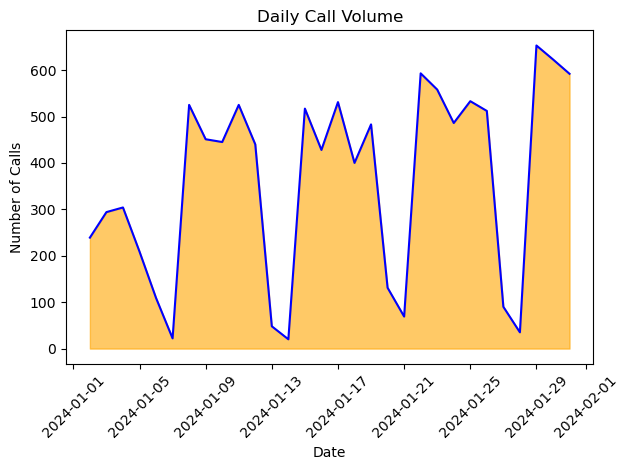

In [15]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [17]:
df1['day'] = df1['Activity date'].dt.day_name()

In [18]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-01-02 08:45:00,NaN,00:01:09,Adrian Tran,Tuesday
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday
2,2024-01-02 09:19:00,Inbound,00:07:00,Robin Stoehr,Tuesday
3,2024-01-02 09:27:00,NaN,00:01:05,Robin Stoehr,Tuesday
4,2024-01-02 09:31:00,Outbound,00:01:18,Robin Stoehr,Tuesday


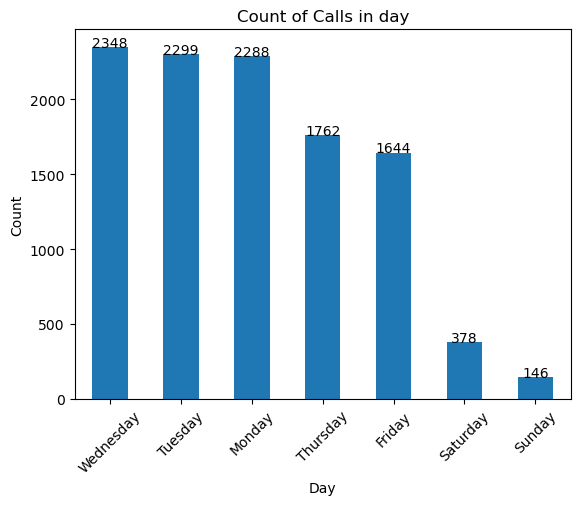

In [19]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")
plt.title("Count of Calls in day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

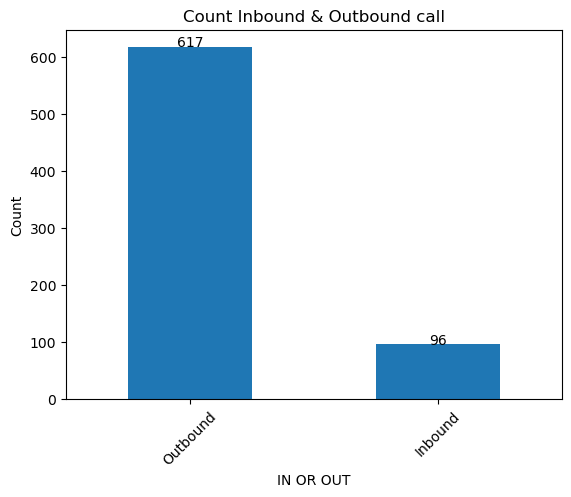

In [21]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [23]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

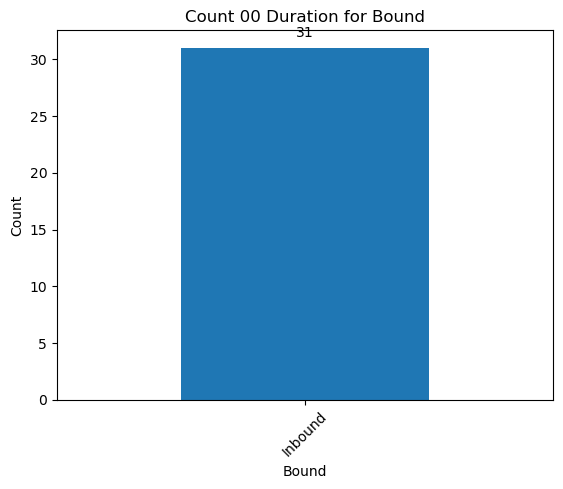

In [24]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [26]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1,2024-01-02 09:15:00,Outbound,NaN,Robin Stoehr,Tuesday
239,2024-01-03 09:04:00,Inbound,NaN,Robin Stoehr,Wednesday
246,2024-01-03 09:48:00,Outbound,NaN,Robin Stoehr,Wednesday
251,2024-01-03 10:20:00,Outbound,NaN,Robin Stoehr,Wednesday
425,2024-01-03 14:17:00,Outbound,NaN,Jinky Rance,Wednesday
...,...,...,...,...,...
9765,2024-01-30 11:49:00,Inbound,NaN,Robin Stoehr,Tuesday
9786,2024-01-30 12:00:00,Outbound,NaN,Chrystel Manabat,Tuesday
9877,2024-01-30 13:43:00,Inbound,NaN,Robin Stoehr,Tuesday
10325,2024-01-31 10:33:00,Outbound,NaN,Robin Stoehr,Wednesday


In [27]:
df4 = df1.copy()

In [28]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [29]:
(df4['Call duration'] == 0).sum()

31

In [30]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10865 entries, 0 to 10864
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10865 non-null  datetime64[us]
 1   Call direction        713 non-null    str           
 2   Call duration         10347 non-null  float64       
 3   Activity assigned to  10829 non-null  str           
 4   day                   10865 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 639.0 KB


In [31]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [32]:
df4 = df4.dropna(subset = ['Call direction'])

In [33]:
(df4['Call duration'] == 0).sum()

142

In [34]:
df4.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 1 to 10701
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         713 non-null    datetime64[us]
 1   Call direction        713 non-null    str           
 2   Call duration         713 non-null    float64       
 3   Activity assigned to  682 non-null    str           
 4   day                   713 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 52.6 KB


# Working Call Assigner

In [36]:
df1['Activity assigned to'].nunique()

25

In [37]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[        'Adrian Tran',        'Robin Stoehr',       'Keith Antonio',
      'Cameron Dudley',    'Vladimir Suparto',        'Dioni Canega',
         'Sal Berdayi',       'Oliver Martin',         'Jinky Rance',
        'Karen Parker',       'Sam Steindorf',        'Louis Maciel',
    'Chrystel Manabat',                   nan,        'David Valdez',
      'David Banister',         'Paol Guzman',       'Garrett Evans',
        'Ray Levesque', 'Demmie Rose Tamonan',     'Adonis Baybayan',
          'Henry Good',        'Bill Goodwin',           'Terry Kim',
           'Juan Calo',   'Brittany Digiulio']
Length: 26, dtype: str

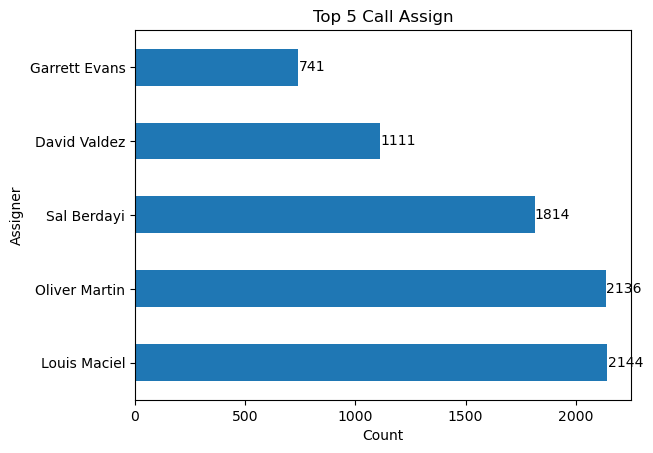

In [38]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [40]:
df4['Call duration'].max()

48.266666666666666

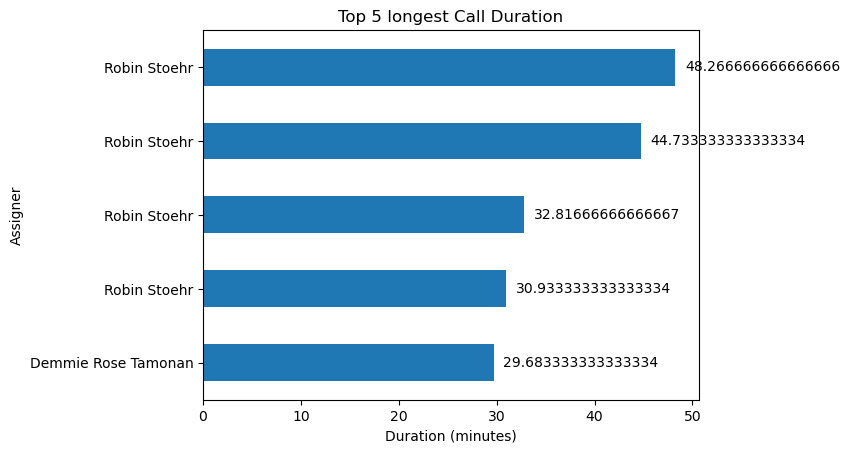

In [41]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [43]:
df3 = df1.copy()

In [44]:
df3 = df3[~df3['day'].isin(['Saturday','Sunday'])]

In [45]:
df3['day'].unique()

<ArrowStringArray>
['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Monday']
Length: 5, dtype: str

In [46]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

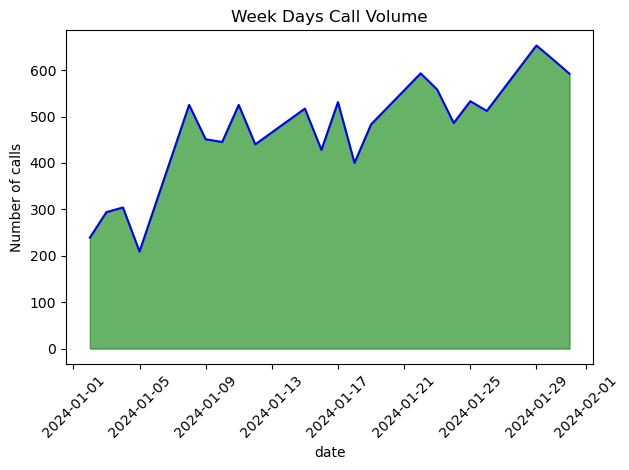

In [47]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 5 Peak Call date

In [49]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [50]:
top5 = daily_calls.sort_values(ascending=False).head(5)

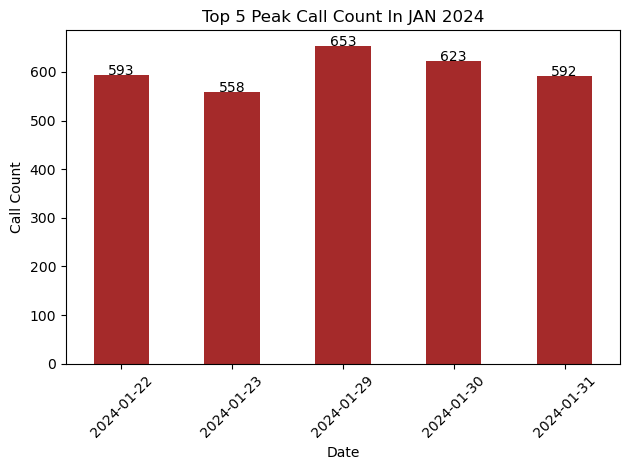

In [95]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JAN 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()